In [4]:
!pip install statsmodels
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                               GradientBoostingClassifier)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Consistent colour palette
PALETTE = "Set2"
CHURN_COLORS = {"No": "#4CAF50", "Yes": "#F44336"}
sns.set_theme(style="whitegrid", palette=PALETTE)

In [35]:
gd = pd.read_csv("gaming_dataset.csv")
df_raw = gd.copy()
gd.head()

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel,Churn
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium,No
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium,No
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High,No
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium,No
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium,No


In [7]:
gd.dtypes

PlayerID                       int64
Age                            int64
Gender                           str
Location                         str
GameGenre                        str
PlayTimeHours                float64
InGamePurchases                int64
GameDifficulty                   str
SessionsPerWeek                int64
AvgSessionDurationMinutes      int64
PlayerLevel                    int64
AchievementsUnlocked           int64
EngagementLevel                  str
Churn                            str
dtype: object

In [8]:
gd.describe(include="all")

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel,Churn
count,40034.000000,40034.000000,40034,40034,40034,40034.000000,40034.000000,40034,40034.000000,40034.000000,40034.000000,40034.000000,40034,40034
unique,NaN,NaN,2,4,5,NaN,NaN,3,NaN,NaN,NaN,NaN,3,2
top,NaN,NaN,Male,USA,Sports,NaN,NaN,Easy,NaN,NaN,NaN,NaN,Medium,No
freq,NaN,NaN,23959,16000,8048,NaN,NaN,20015,NaN,NaN,NaN,NaN,19374,29710
mean,29016.500000,31.992531,NaN,NaN,NaN,12.024365,0.200854,NaN,9.471774,94.792252,49.655568,24.526477,NaN,NaN
std,11556.964675,10.043227,NaN,NaN,NaN,6.914638,0.400644,NaN,5.763667,49.011375,28.588379,14.430726,NaN,NaN
min,9000.000000,15.000000,NaN,NaN,NaN,0.000115,0.000000,NaN,0.000000,10.000000,1.000000,0.000000,NaN,NaN
25%,19008.250000,23.000000,NaN,NaN,NaN,6.067501,0.000000,NaN,4.000000,52.000000,25.000000,12.000000,NaN,NaN
50%,29016.500000,32.000000,NaN,NaN,NaN,12.008002,0.000000,NaN,9.000000,95.000000,49.000000,25.000000,NaN,NaN
75%,39024.750000,41.000000,NaN,NaN,NaN,17.963831,0.000000,NaN,14.000000,137.000000,74.000000,37.000000,NaN,NaN


In [9]:
print(gd.isnull().sum())

PlayerID                     0
Age                          0
Gender                       0
Location                     0
GameGenre                    0
PlayTimeHours                0
InGamePurchases              0
GameDifficulty               0
SessionsPerWeek              0
AvgSessionDurationMinutes    0
PlayerLevel                  0
AchievementsUnlocked         0
EngagementLevel              0
Churn                        0
dtype: int64


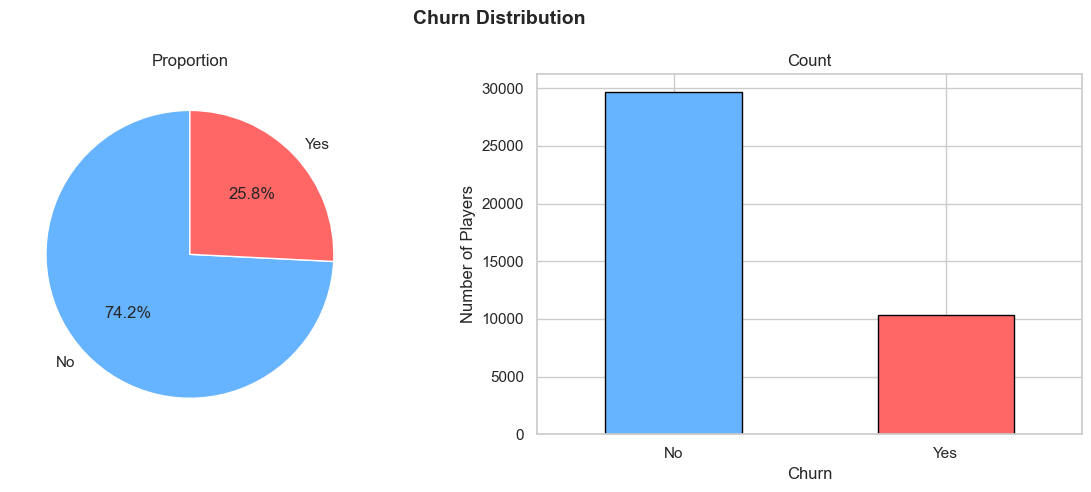

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Churn Distribution", fontsize=14, fontweight="bold")

churn_counts = gd['Churn'].value_counts()
axes[0].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
            colors=['#66b3ff', '#ff6666'], startangle=90)
axes[0].set_title("Proportion")

churn_counts.plot(kind='bar', ax=axes[1], color=['#66b3ff', '#ff6666'],
                  edgecolor='black')
axes[1].set_title("Count")
axes[1].set_xlabel("Churn")
axes[1].set_ylabel("Number of Players")
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

In [11]:
print("\nClass balance:")
print(churn_counts)
churn_pct = churn_counts / len(gd) * 100
print(f"\nChurn rate: {churn_pct.get('Yes', 0):.2f}%")
if churn_pct.get('Yes', 0) < 30 or churn_pct.get('Yes', 0) > 70:
    print("  -> Mild or moderate class imbalance detected.")
    print("     Stratified split will be used; monitor Recall & F1.")


Class balance:
Churn
No     29710
Yes    10324
Name: count, dtype: int64

Churn rate: 25.79%
  -> Mild or moderate class imbalance detected.
     Stratified split will be used; monitor Recall & F1.


C:\Users\navya\AppData\Local\Temp\ipykernel_23700\4090179165.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='ChurnRate', data=churn_rate, ax=axes[1],


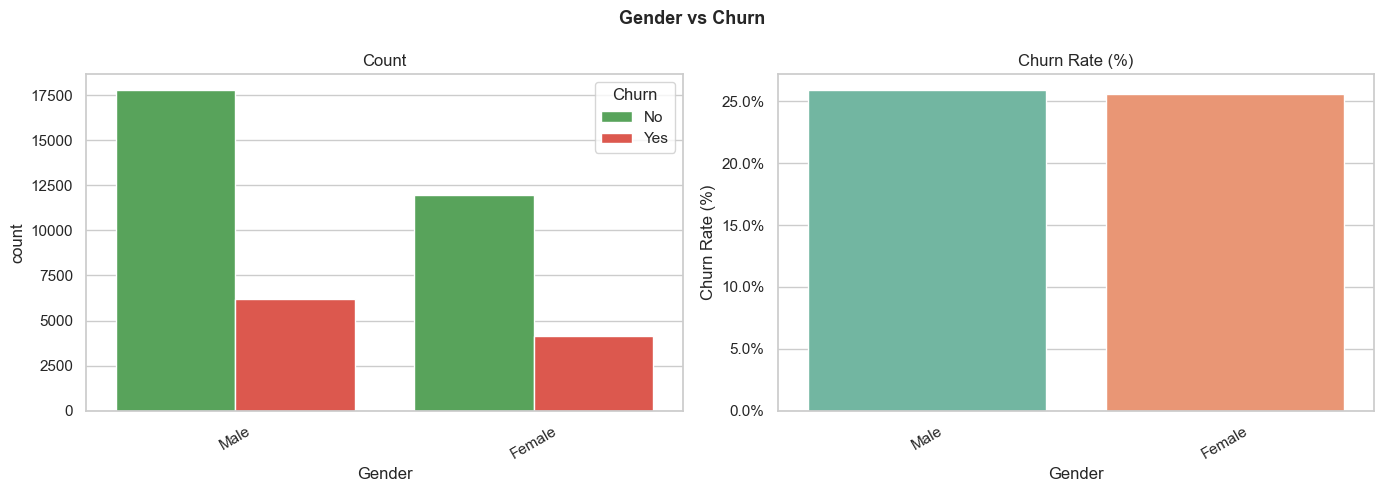

C:\Users\navya\AppData\Local\Temp\ipykernel_23700\4090179165.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='ChurnRate', data=churn_rate, ax=axes[1],


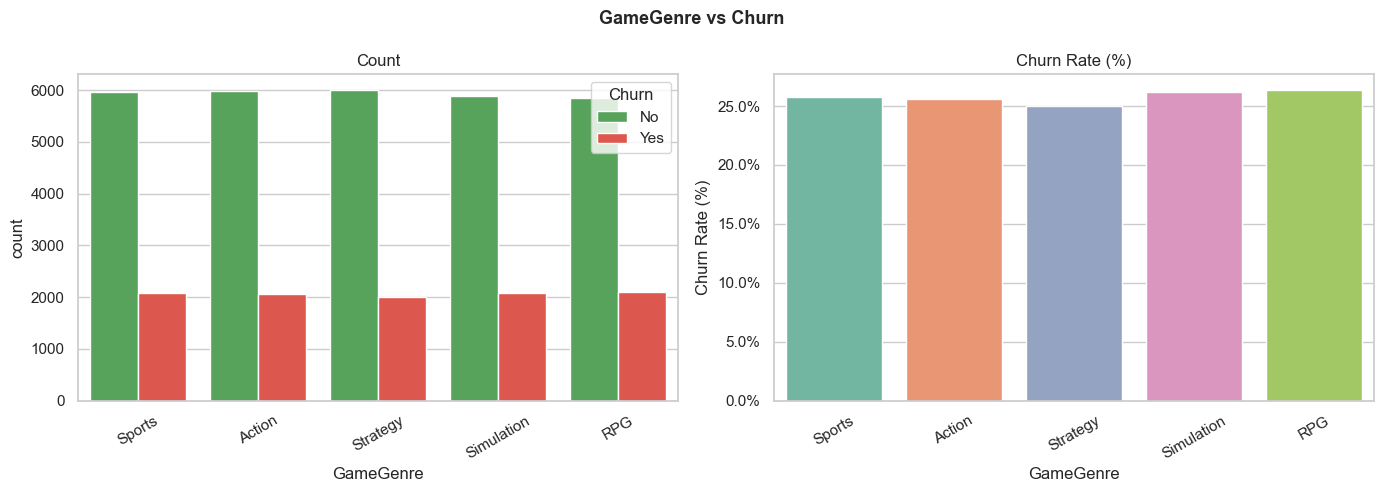

C:\Users\navya\AppData\Local\Temp\ipykernel_23700\4090179165.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='ChurnRate', data=churn_rate, ax=axes[1],


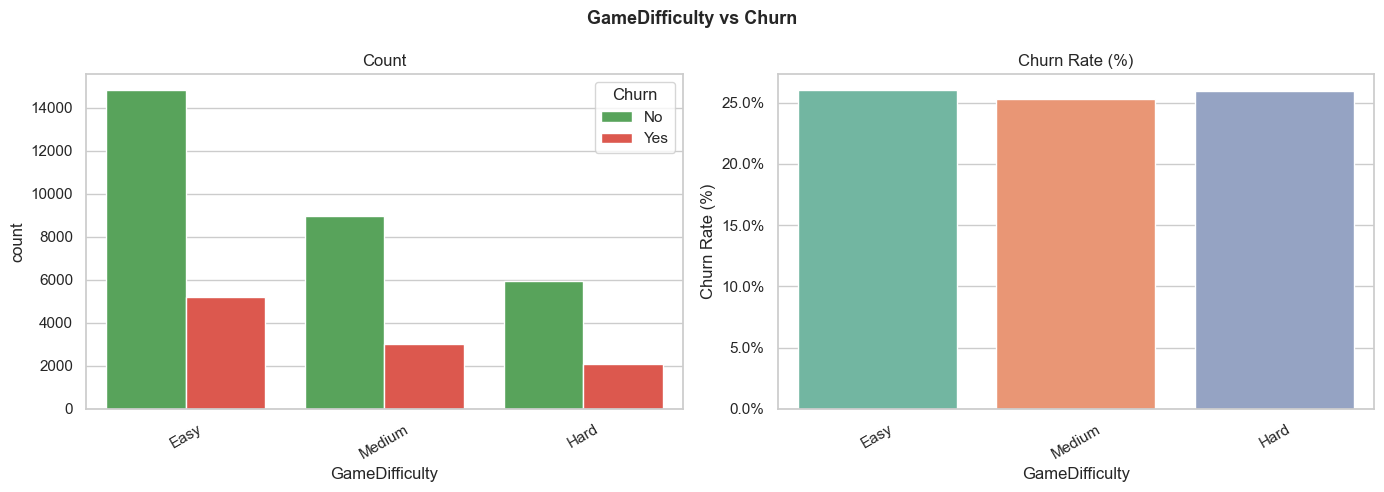

C:\Users\navya\AppData\Local\Temp\ipykernel_23700\4090179165.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='ChurnRate', data=churn_rate, ax=axes[1],


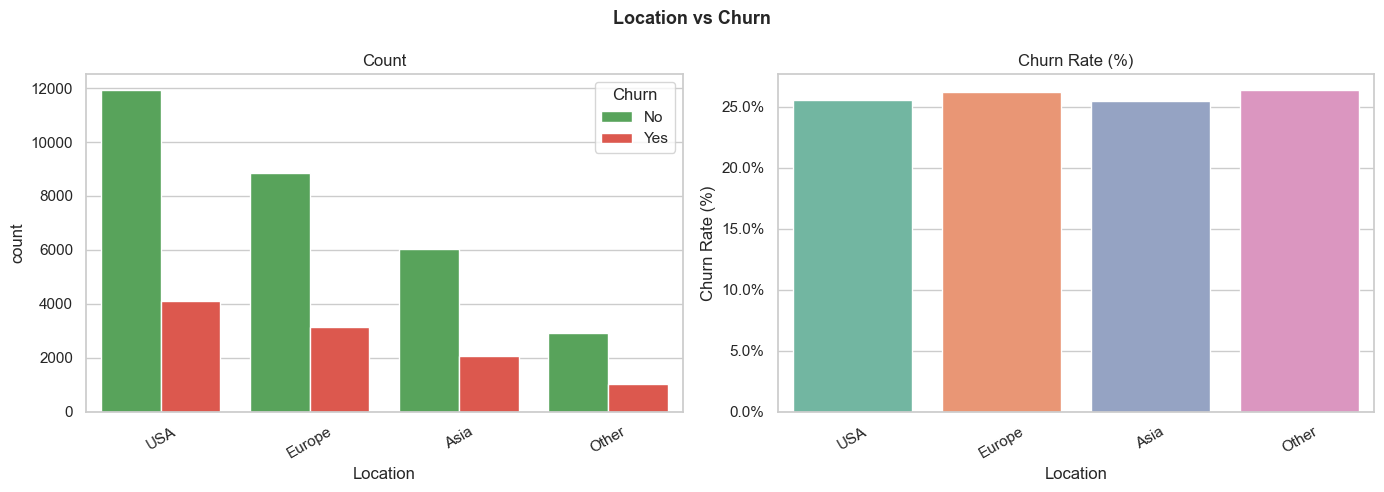

C:\Users\navya\AppData\Local\Temp\ipykernel_23700\4090179165.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='ChurnRate', data=churn_rate, ax=axes[1],


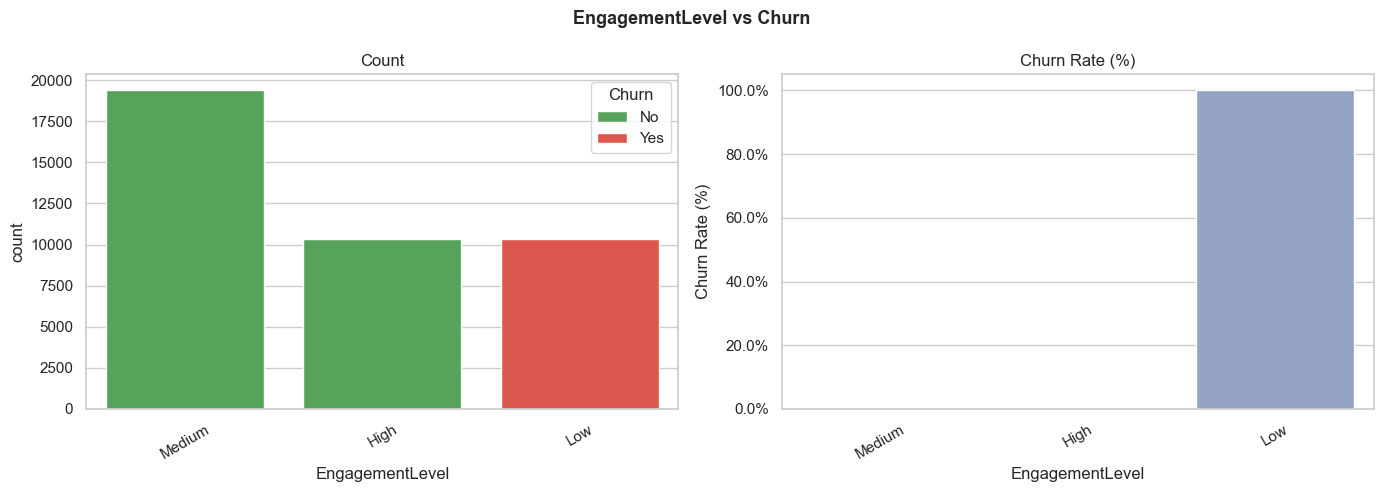

In [17]:
cat_cols = ['Gender', 'GameGenre', 'GameDifficulty', 'Location', 'EngagementLevel']

for col in cat_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{col} vs Churn", fontsize=13, fontweight="bold")

    # Count plot
    sns.countplot(x=col, hue="Churn", data=gd, ax=axes[0],
                  palette=CHURN_COLORS, order=gd[col].value_counts().index)
    axes[0].set_title("Count")
    axes[0].set_xlabel(col)
    axes[0].tick_params(axis='x', rotation=30)

    # Churn rate per category
    churn_rate = (gd.groupby(col)['Churn']
                    .apply(lambda x: (x == 'Yes').mean() * 100)
                    .reset_index(name='ChurnRate'))
    sns.barplot(x=col, y='ChurnRate', data=churn_rate, ax=axes[1],
                palette=PALETTE,
                order=gd[col].value_counts().index)
    axes[1].set_title("Churn Rate (%)")
    axes[1].set_xlabel(col)
    axes[1].set_ylabel("Churn Rate (%)")
    axes[1].tick_params(axis='x', rotation=30)
    axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
    plt.tight_layout()
    plt.show()

In [18]:
print("\nClass balance:")
print(churn_counts)
churn_pct = churn_counts / len(gd) * 100
print(f"\nChurn rate: {churn_pct.get('Yes', 0):.2f}%")
if churn_pct.get('Yes', 0) < 30 or churn_pct.get('Yes', 0) > 70:
    print("  -> Mild or moderate class imbalance detected.")
    print("     Stratified split will be used; monitor Recall & F1.")


Class balance:
Churn
No     29710
Yes    10324
Name: count, dtype: int64

Churn rate: 25.79%
  -> Mild or moderate class imbalance detected.
     Stratified split will be used; monitor Recall & F1.


C:\Users\navya\AppData\Local\Temp\ipykernel_23700\3409226364.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=gd, ax=axes[1],


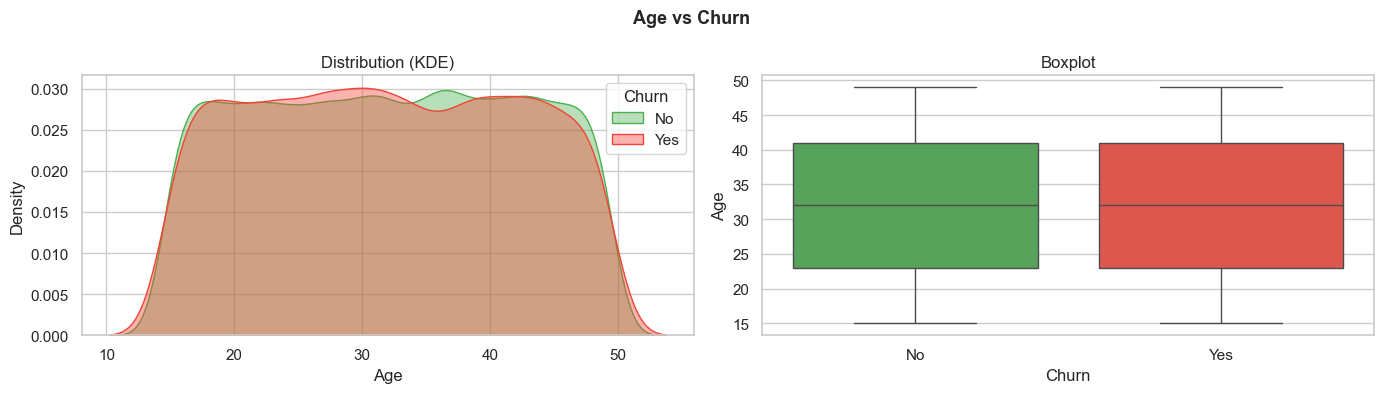

C:\Users\navya\AppData\Local\Temp\ipykernel_23700\3409226364.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=gd, ax=axes[1],


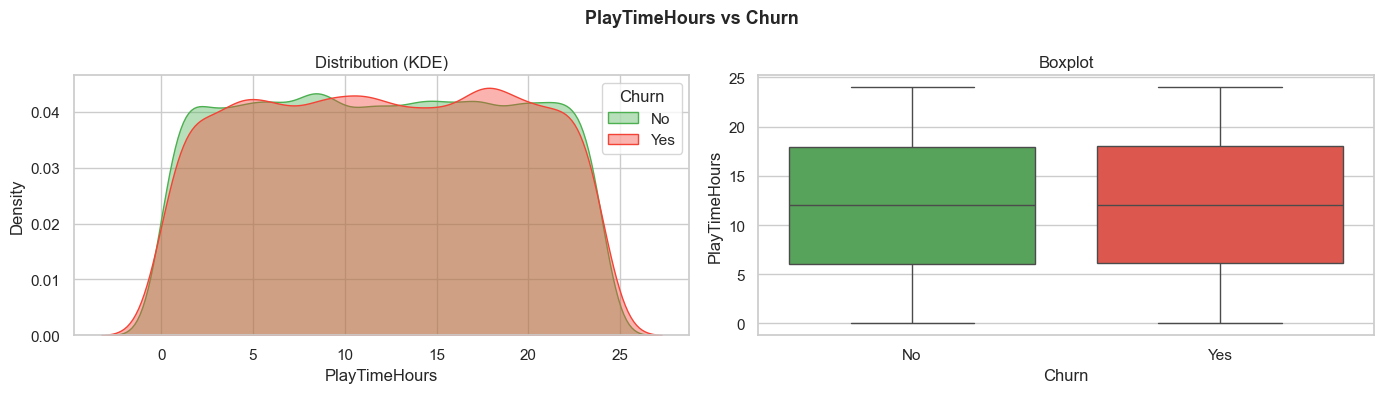

C:\Users\navya\AppData\Local\Temp\ipykernel_23700\3409226364.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=gd, ax=axes[1],


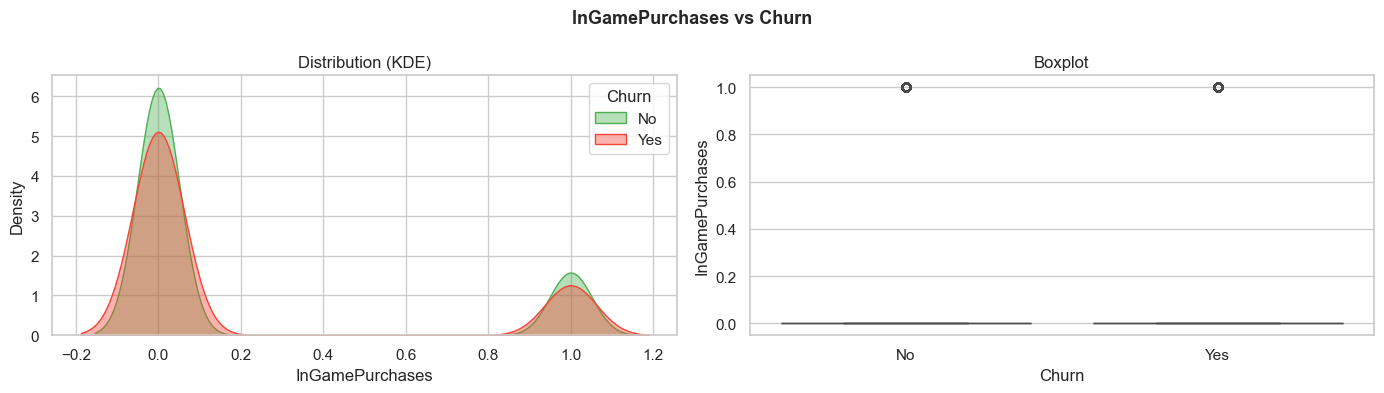

C:\Users\navya\AppData\Local\Temp\ipykernel_23700\3409226364.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=gd, ax=axes[1],


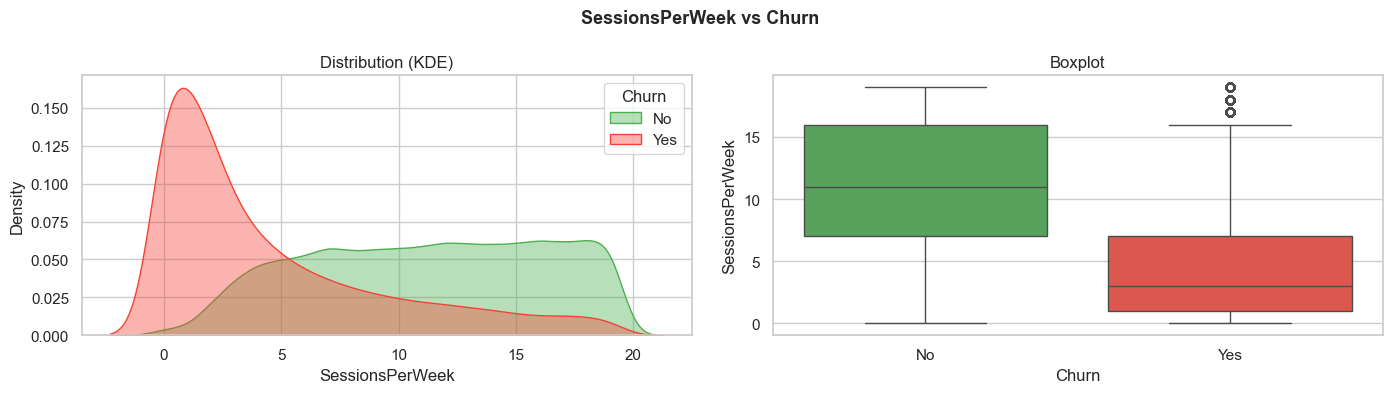

C:\Users\navya\AppData\Local\Temp\ipykernel_23700\3409226364.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=gd, ax=axes[1],


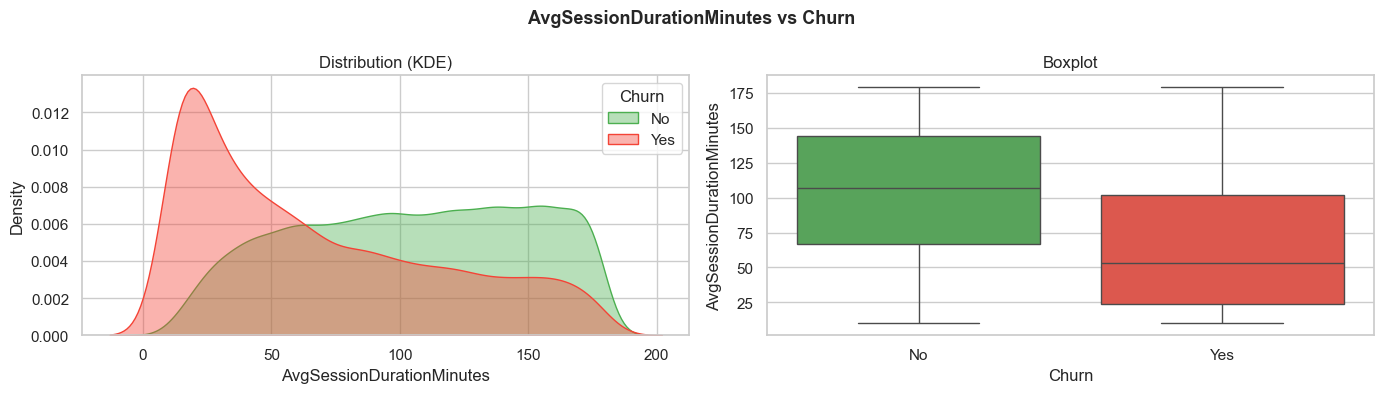

C:\Users\navya\AppData\Local\Temp\ipykernel_23700\3409226364.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=gd, ax=axes[1],


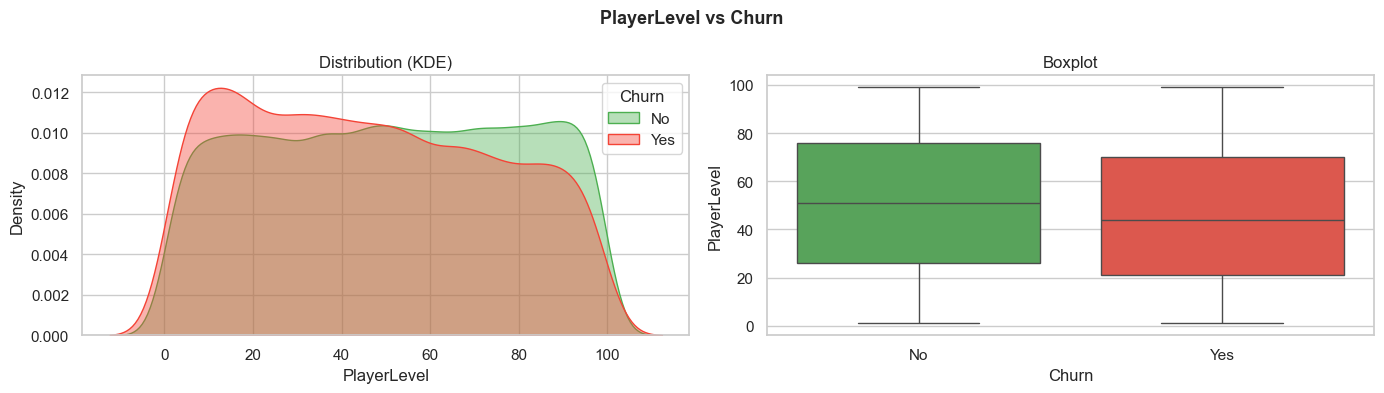

C:\Users\navya\AppData\Local\Temp\ipykernel_23700\3409226364.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=gd, ax=axes[1],


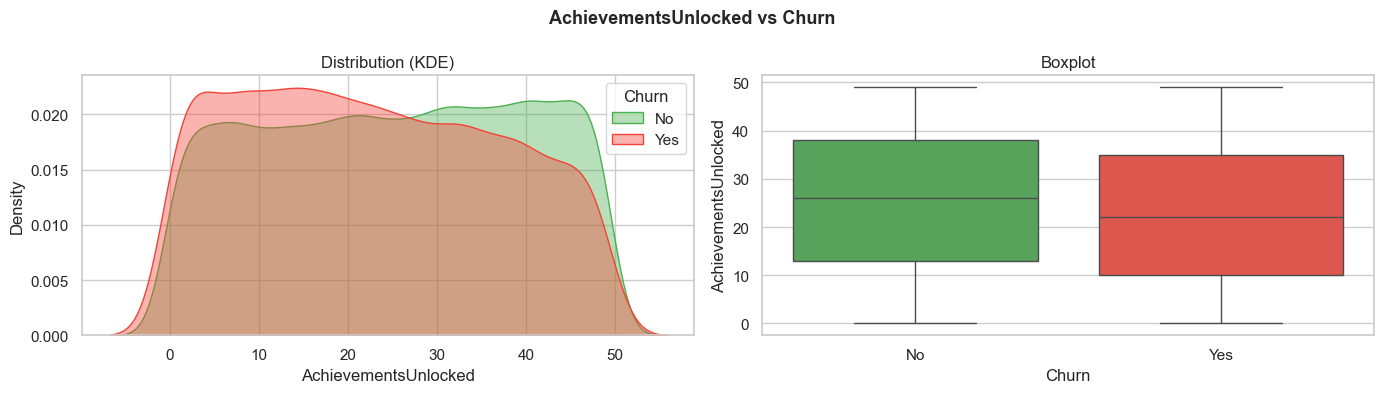

In [19]:
num_cols = ['Age', 'PlayTimeHours', 'InGamePurchases', 'SessionsPerWeek',
            'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked']

for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f"{col} vs Churn", fontsize=13, fontweight="bold")

    # KDE plot
    # FIX: shade= was deprecated in newer seaborn; replaced with fill=
    for label, colour in CHURN_COLORS.items():
        subset = gd[gd['Churn'] == label][col]
        sns.kdeplot(subset, ax=axes[0], color=colour, fill=True,
                    alpha=0.4, label=label)
    axes[0].set_title("Distribution (KDE)")
    axes[0].set_xlabel(col)
    axes[0].legend(title="Churn")

    # Boxplot
    sns.boxplot(x='Churn', y=col, data=gd, ax=axes[1],
                palette=CHURN_COLORS, order=['No', 'Yes'])
    axes[1].set_title("Boxplot")
    axes[1].set_xlabel("Churn")
    axes[1].set_ylabel(col)

    plt.tight_layout()
    plt.show()


In [21]:
corr_data = gd.copy()
corr_data['Churn_num'] = corr_data['Churn'].map({'Yes': 1, 'No': 0})

numeric_data = corr_data.select_dtypes(include=[np.number])

# 5.1 Correlation with Churn
corr_with_churn = (numeric_data.corr()['Churn_num']
                               .drop('Churn_num')
                               .sort_values(key=abs, ascending=False))
print("\nCorrelation with Churn (sorted by absolute value):")
print(corr_with_churn.round(4))



Correlation with Churn (sorted by absolute value):
SessionsPerWeek             -0.5054
AvgSessionDurationMinutes   -0.3357
AchievementsUnlocked        -0.0762
PlayerLevel                 -0.0733
PlayTimeHours                0.0069
Age                         -0.0056
InGamePurchases             -0.0052
PlayerID                     0.0039
Name: Churn_num, dtype: float64


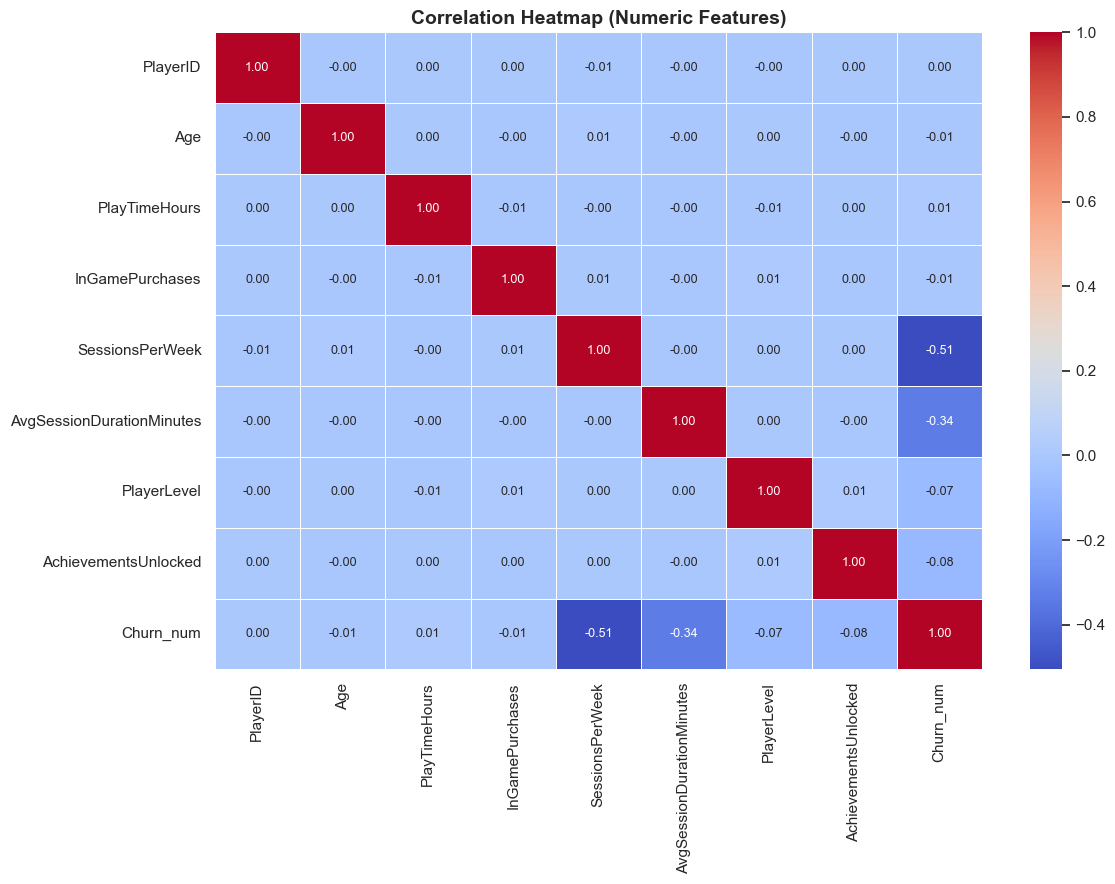

In [22]:
corr_matrix = numeric_data.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f",
            linewidths=0.5, annot_kws={"size": 9})
plt.title("Correlation Heatmap (Numeric Features)", fontsize=14,
          fontweight="bold")
plt.tight_layout()
plt.show()

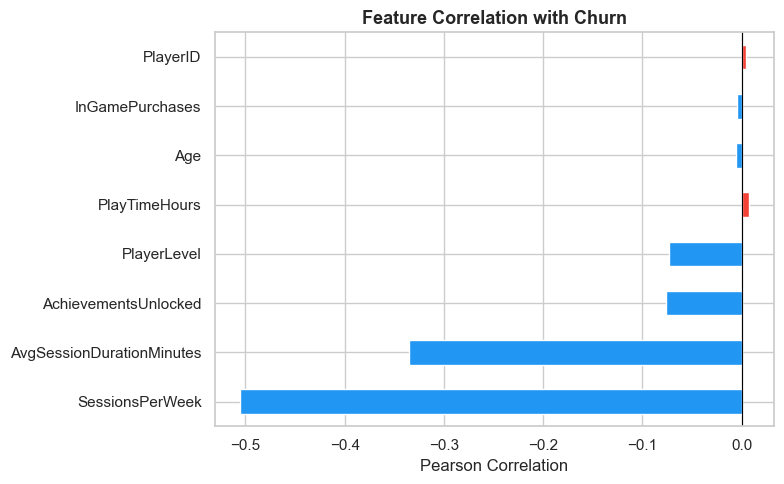

In [23]:
plt.figure(figsize=(8, 5))
colors = ['#F44336' if v > 0 else '#2196F3' for v in corr_with_churn]
corr_with_churn.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Feature Correlation with Churn", fontsize=13, fontweight="bold")
plt.xlabel("Pearson Correlation")
plt.tight_layout()
plt.show()

In [24]:
vif_features = numeric_data.drop(columns=['Churn_num']).dropna()
vif_df = pd.DataFrame({
    "Feature": vif_features.columns,
    "VIF": [variance_inflation_factor(vif_features.values, i)
            for i in range(vif_features.shape[1])]
}).sort_values("VIF", ascending=False).reset_index(drop=True)

print("\nVIF Table:")
print(vif_df.round(2))

high_vif = vif_df[vif_df["VIF"] > 5]["Feature"].tolist()
if high_vif:
    print(f"\n  -> High VIF features (>5): {high_vif}")
    print("     Consider removing or combining these in production models.")
else:
    print("\n  -> No severe multicollinearity detected (all VIF ≤ 5). ✓")


VIF Table:
                     Feature   VIF
0                        Age  7.74
1                   PlayerID  5.89
2  AvgSessionDurationMinutes  4.19
3                PlayerLevel  3.66
4              PlayTimeHours  3.65
5       AchievementsUnlocked  3.56
6            SessionsPerWeek  3.41
7            InGamePurchases  1.24

  -> High VIF features (>5): ['Age', 'PlayerID']
     Consider removing or combining these in production models.


In [25]:
gd['EngagementScore'] = gd['SessionsPerWeek'] * gd['AvgSessionDurationMinutes']

# 7.2 Achievements Per Level: productivity relative to progress
# Add 1 to PlayerLevel to prevent division by zero
gd['AchievementsPerLevel'] = gd['AchievementsUnlocked'] / (gd['PlayerLevel'] + 1)

print("\nSample of engineered features:")
print(gd[['EngagementScore', 'AchievementsPerLevel']].describe())

# NaN guard after feature engineering
assert gd[['EngagementScore', 'AchievementsPerLevel']].isnull().sum().sum() == 0, \
    "NaN in engineered features!"
print("[CHECK] No NaN in engineered features. ✓")


Sample of engineered features:
       EngagementScore  AchievementsPerLevel
count     40034.000000          40034.000000
mean        897.675676              1.037468
std         771.280437              2.003991
min           0.000000              0.000000
25%         268.000000              0.236111
50%         684.000000              0.486664
75%        1364.000000              0.942025
max        3401.000000             24.500000
[CHECK] No NaN in engineered features. ✓


In [26]:
gd['Churn'] = gd['Churn'].map({'Yes': 1, 'No': 0})
print(f"\nChurn value counts after encoding:\n{gd['Churn'].value_counts()}")


Churn value counts after encoding:
Churn
0    29710
1    10324
Name: count, dtype: int64


In [28]:
le = LabelEncoder()

# Gender: binary (Male/Female) — label encoding is fine
gd['Gender'] = le.fit_transform(gd['Gender'])

# GameDifficulty: Easy < Medium < Hard — ordinal, label encode is fine
# FIX: LabelEncoder assigns alphabetical order (Easy=0, Hard=1, Medium=2),
#      which is NOT the correct difficulty order.
#      We use an explicit ordered map instead.
diff_map = {'Easy': 0, 'Medium': 1, 'Hard': 2}
gd['GameDifficulty'] = gd['GameDifficulty'].map(diff_map)
eng_map = {'Low': 0, 'Medium': 1, 'High': 2}
# FIX: EngagementLevel column existed in the dataset but was completely
#      missing from the original code, so it would have caused an error
#      during get_dummies (or been silently ignored).  We encode it here.
gd['EngagementLevel'] = gd['EngagementLevel'].map(eng_map)

In [36]:
gd = df_raw.copy()
print("Restored original dataset successfully!")
gd.columns.tolist()

Restored original dataset successfully!


['PlayerID',
 'Age',
 'Gender',
 'Location',
 'GameGenre',
 'PlayTimeHours',
 'InGamePurchases',
 'GameDifficulty',
 'SessionsPerWeek',
 'AvgSessionDurationMinutes',
 'PlayerLevel',
 'AchievementsUnlocked',
 'EngagementLevel',
 'Churn']

In [37]:
gd = pd.get_dummies(gd, columns=['Location', 'GameGenre'], drop_first=True)

print("\nColumns after all encoding:")
print(gd.columns.tolist())

# NaN guard after encoding
assert gd.isnull().sum().sum() == 0, "NaN introduced during encoding!"
print("\n[CHECK] No NaN after encoding. ✓")


Columns after all encoding:
['PlayerID', 'Age', 'Gender', 'PlayTimeHours', 'InGamePurchases', 'GameDifficulty', 'SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked', 'EngagementLevel', 'Churn', 'Location_Europe', 'Location_Other', 'Location_USA', 'GameGenre_RPG', 'GameGenre_Simulation', 'GameGenre_Sports', 'GameGenre_Strategy']

[CHECK] No NaN after encoding. ✓


In [39]:
gd["Churn"] = gd["Churn"].str.strip().str.lower().map({"yes": 1, "no": 0})

In [41]:
X = gd.drop("Churn", axis=1)
y = gd["Churn"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(f"\nTraining set : {X_train.shape}")
print(f"Testing set  : {X_test.shape}")

print(f"Train churn % : {y_train.mean() * 100:.2f}%")
print(f"Test  churn % : {y_test.mean() * 100:.2f}%")


Training set : (28023, 18)
Testing set  : (12011, 18)
Train churn % : 25.79%
Test  churn % : 25.78%


In [43]:
gd.head()

,PlayerID,Age,Gender,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel,Churn,Location_Europe,Location_Other,Location_USA,GameGenre_RPG,GameGenre_Simulation,GameGenre_Sports,GameGenre_Strategy
0,9000,43,Male,16.271119,0,Medium,6,108,79,25,Medium,0,False,True,False,False,False,False,True
1,9001,29,Female,5.525961,0,Medium,5,144,11,10,Medium,0,False,False,True,False,False,False,True
2,9002,22,Female,8.223755,0,Easy,16,142,35,41,High,0,False,False,True,False,False,True,False
3,9003,35,Male,5.265351,1,Easy,9,85,57,47,Medium,0,False,False,True,False,False,False,False
4,9004,33,Male,15.531945,0,Medium,2,131,95,37,Medium,0,True,False,False,False,False,False,False


In [44]:
numeric_scale_cols = ['Age', 'PlayTimeHours', 'InGamePurchases',
                      'SessionsPerWeek', 'AvgSessionDurationMinutes',
                      'PlayerLevel', 'AchievementsUnlocked']

scaler = StandardScaler()
X_train = X_train.copy()
X_test  = X_test.copy()
X_train[numeric_scale_cols] = scaler.fit_transform(X_train[numeric_scale_cols])
X_test[numeric_scale_cols]  = scaler.transform(X_test[numeric_scale_cols])

# NaN guard after scaling
assert X_train.isnull().sum().sum() == 0, "NaN in X_train after scaling!"
assert X_test.isnull().sum().sum() == 0, "NaN in X_test after scaling!"
print("\n[CHECK] No NaN after scaling. ✓")



[CHECK] No NaN after scaling. ✓


In [46]:
cat_cols = X_train.select_dtypes(include='object').columns
print(cat_cols)

Index(['Gender', 'GameDifficulty', 'EngagementLevel'], dtype='str')


C:\Users\navya\AppData\Local\Temp\ipykernel_23700\897766313.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include='object').columns


In [47]:
gd = df_raw.copy()

# target encoding
gd["Churn"] = gd["Churn"].str.strip().str.lower().map({"yes": 1, "no": 0})

# encode ALL categorical columns automatically
gd = pd.get_dummies(gd, drop_first=True)

# split again
from sklearn.model_selection import train_test_split

X = gd.drop("Churn", axis=1)
y = gd["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

In [48]:
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"Trained: {name}")

print("All models trained successfully!")

C:\Users\navya\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Trained: Logistic Regression
Trained: KNN
Trained: Decision Tree
Trained: Random Forest
Trained: Extra Trees
Trained: Gradient Boosting
All models trained successfully!


In [63]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Data split done")
print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Data split done
Train shape: (28023, 20)
Test shape : (12011, 20)


In [65]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [67]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):

    print(f"\nRunning: {name}")

    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_te)[:, 1]
    else:
        y_proba = model.decision_function(X_te)

    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec = recall_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    roc_auc = roc_auc_score(y_te, y_proba)

    cv_scores = cross_val_score(
        model, X_tr, y_tr,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1
    )

    print("\n" + "─"*50)
    print(f" {name}")
    print("─"*50)
    print(f" Accuracy   : {acc:.4f}")
    print(f" Precision  : {prec:.4f}")
    print(f" Recall     : {rec:.4f}")
    print(f" F1 Score   : {f1:.4f}")
    print(f" ROC-AUC    : {roc_auc:.4f}")
    print(f" CV ROC-AUC : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

    print("\nClassification Report:")
    print(classification_report(y_te, y_pred, target_names=["Retained", "Churned"]))

for name, model in models.items():
    evaluate_model(name, model, X_train, y_train, X_test, y_test)

print("\nALL MODELS COMPLETED ✓")


Running: Logistic Regression


C:\Users\navya\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



──────────────────────────────────────────────────
 Logistic Regression
──────────────────────────────────────────────────
 Accuracy   : 0.9999
 Precision  : 0.9997
 Recall     : 1.0000
 F1 Score   : 0.9998
 ROC-AUC    : 1.0000
 CV ROC-AUC : 1.0000 ± 0.0000

Classification Report:
              precision    recall  f1-score   support

    Retained       1.00      1.00      1.00      8914
     Churned       1.00      1.00      1.00      3097

    accuracy                           1.00     12011
   macro avg       1.00      1.00      1.00     12011
weighted avg       1.00      1.00      1.00     12011


Running: KNN

──────────────────────────────────────────────────
 KNN
──────────────────────────────────────────────────
 Accuracy   : 0.7537
 Precision  : 0.5463
 Recall     : 0.2648
 F1 Score   : 0.3567
 ROC-AUC    : 0.6790
 CV ROC-AUC : 0.6725 ± 0.0070

Classification Report:
              precision    recall  f1-score   support

    Retained       0.78      0.92      0.85      8914


In [75]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
all_proba = {}

In [80]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):

    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_te)[:, 1]
    else:
        y_proba = model.decision_function(X_te)

    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec = recall_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    roc_auc = roc_auc_score(y_te, y_proba)

    cv_scores = cross_val_score(
        model, X_tr, y_tr,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1
    )

    # Confusion matrix
    cm = confusion_matrix(y_te, y_pred)
    plt.figure(figsize=(3, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Retained", "Churned"],
                yticklabels=["Retained", "Churned"])
    plt.title(name)
    plt.show()

    row = {
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "ROC-AUC": roc_auc,
        "CV ROC-AUC": cv_scores.mean()
    }

    return row, y_proba

C:\Users\navya\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


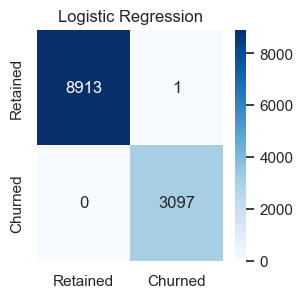

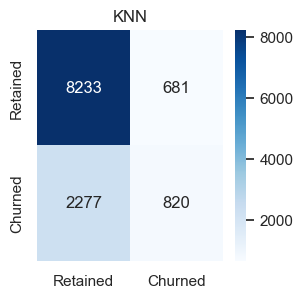

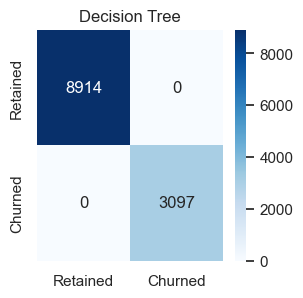

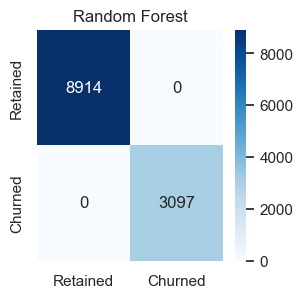

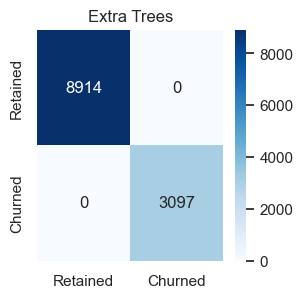

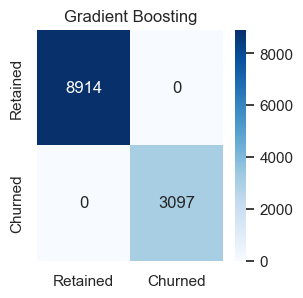

In [81]:
for name, model in models.items():
    row, proba = evaluate_model(name, model, X_train, y_train, X_test, y_test)
    results.append(row)
    all_proba[name] = proba

In [82]:
results_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)
print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC  \
0  Logistic Regression  0.999917   0.999677  1.000000  0.999839  1.000000   
2        Decision Tree  1.000000   1.000000  1.000000  1.000000  1.000000   
4          Extra Trees  1.000000   1.000000  1.000000  1.000000  1.000000   
3        Random Forest  1.000000   1.000000  1.000000  1.000000  1.000000   
5    Gradient Boosting  1.000000   1.000000  1.000000  1.000000  1.000000   
1                  KNN  0.753726   0.546302  0.264772  0.356677  0.679047   

   CV ROC-AUC  
0    1.000000  
2    1.000000  
4    1.000000  
3    1.000000  
5    1.000000  
1    0.672468  


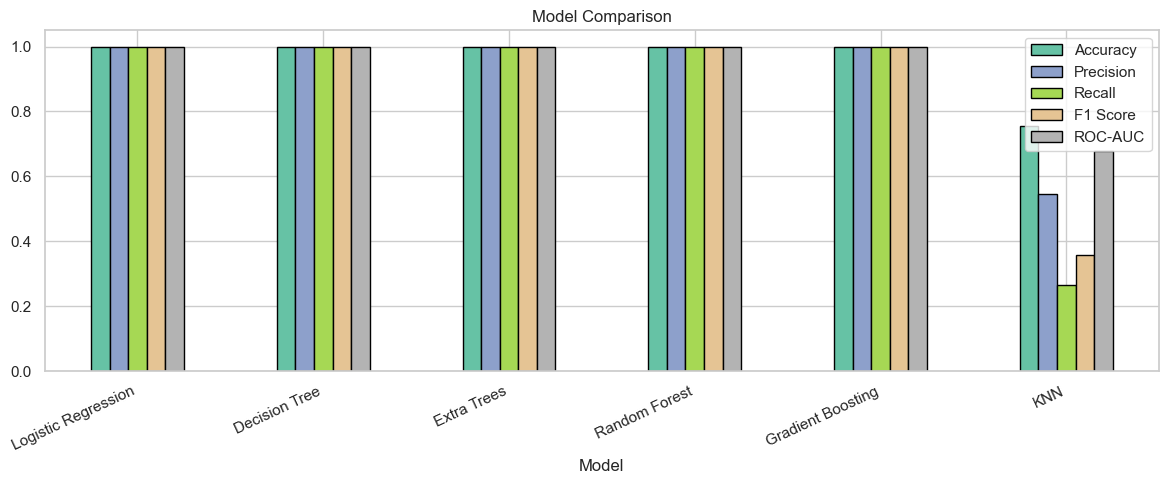

In [83]:
metric_cols = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
plot_df = results_df[["Model"] + metric_cols].set_index("Model")
plot_df.plot(kind="bar", figsize=(12, 5), colormap="Set2", edgecolor="black")
plt.title("Model Comparison")
plt.ylim(0, 1.05)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

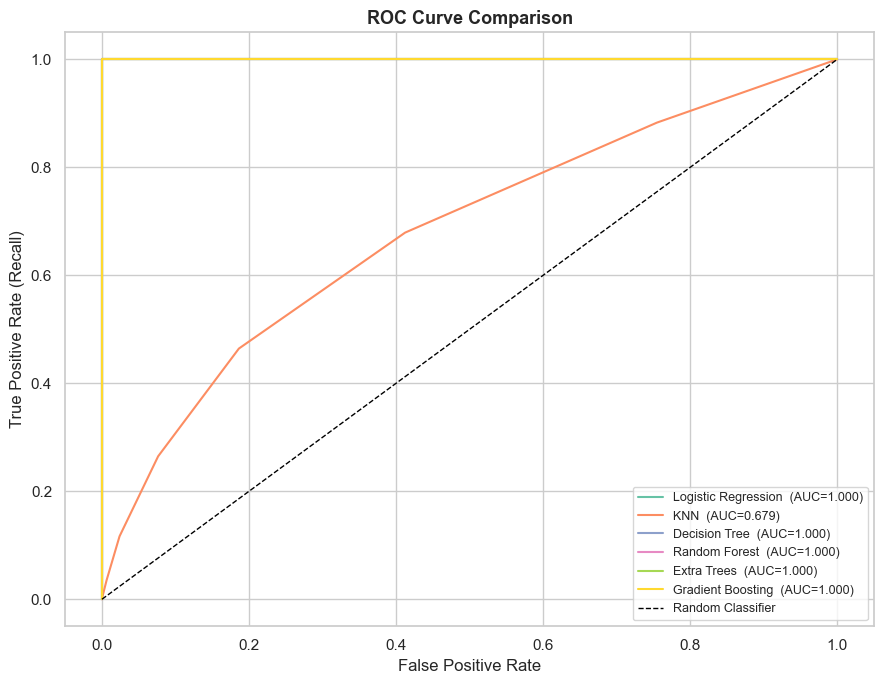

In [84]:
plt.figure(figsize=(9, 7))
for name, proba in all_proba.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name}  (AUC={auc_val:.3f})")

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve Comparison", fontsize=13, fontweight="bold")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

C:\Users\navya\AppData\Local\Temp\ipykernel_23700\3148123591.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=fi, palette="viridis")


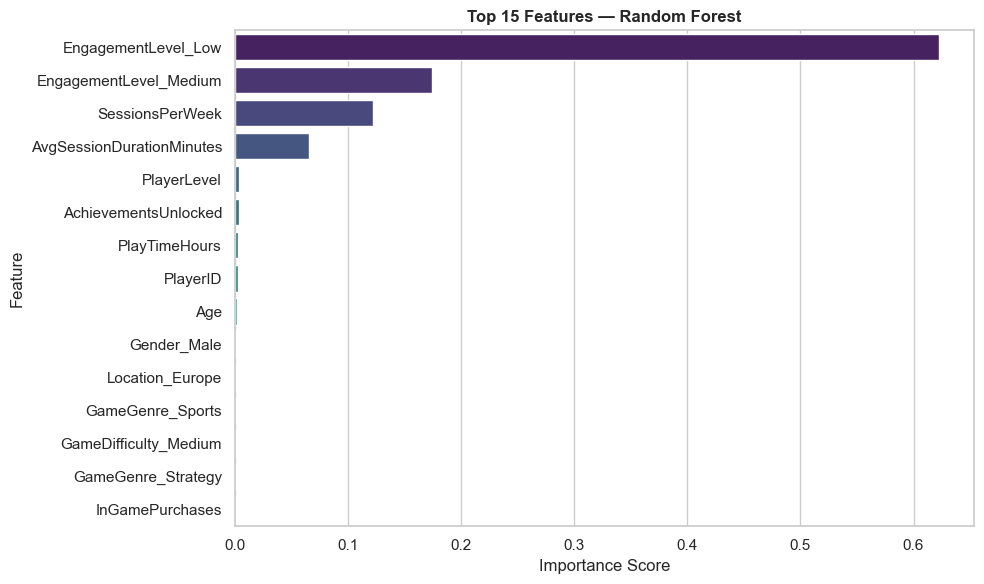


Top 15 features (Random Forest):
                  Feature  Importance
      EngagementLevel_Low    0.622356
   EngagementLevel_Medium    0.173984
          SessionsPerWeek    0.121600
AvgSessionDurationMinutes    0.065601
              PlayerLevel    0.003689
     AchievementsUnlocked    0.003574
            PlayTimeHours    0.002405
                 PlayerID    0.002261
                      Age    0.001779
              Gender_Male    0.000359
          Location_Europe    0.000263
         GameGenre_Sports    0.000255
    GameDifficulty_Medium    0.000251
       GameGenre_Strategy    0.000250
          InGamePurchases    0.000249


C:\Users\navya\AppData\Local\Temp\ipykernel_23700\3148123591.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=fi, palette="viridis")


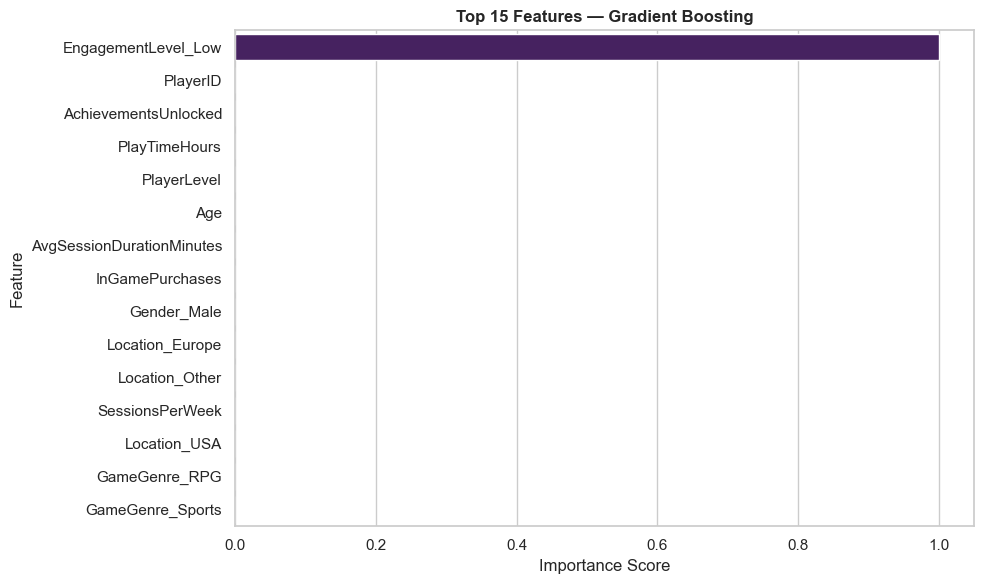


Top 15 features (Gradient Boosting):
                  Feature   Importance
      EngagementLevel_Low 1.000000e+00
                 PlayerID 1.142509e-13
     AchievementsUnlocked 4.832690e-14
            PlayTimeHours 3.455430e-14
              PlayerLevel 8.401783e-15
                      Age 7.057177e-15
AvgSessionDurationMinutes 3.088598e-16
          InGamePurchases 0.000000e+00
              Gender_Male 0.000000e+00
          Location_Europe 0.000000e+00
           Location_Other 0.000000e+00
          SessionsPerWeek 0.000000e+00
             Location_USA 0.000000e+00
            GameGenre_RPG 0.000000e+00
         GameGenre_Sports 0.000000e+00


C:\Users\navya\AppData\Local\Temp\ipykernel_23700\3148123591.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=fi, palette="viridis")


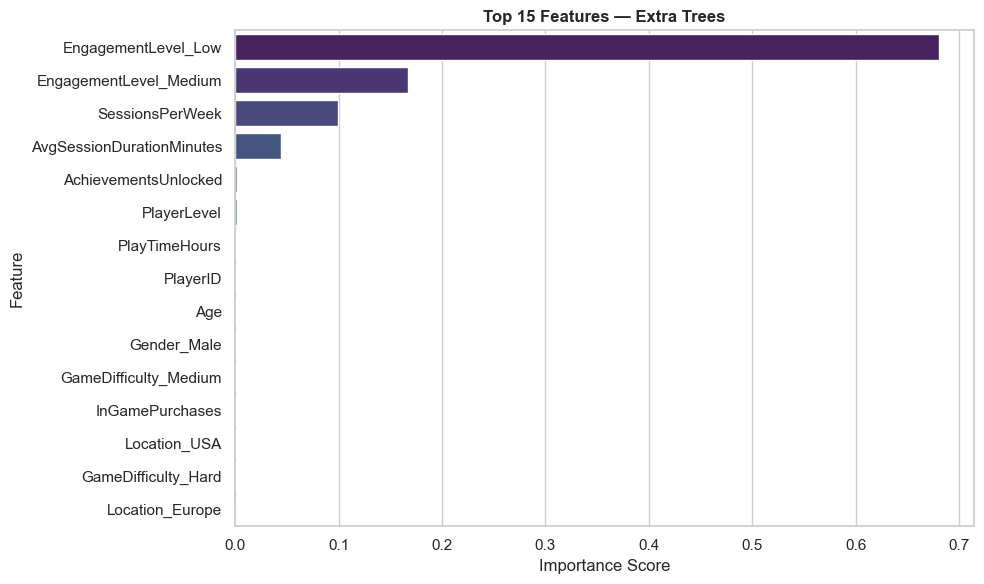


Top 15 features (Extra Trees):
                  Feature  Importance
      EngagementLevel_Low    0.680383
   EngagementLevel_Medium    0.166780
          SessionsPerWeek    0.099815
AvgSessionDurationMinutes    0.044543
     AchievementsUnlocked    0.001907
              PlayerLevel    0.001565
            PlayTimeHours    0.000763
                 PlayerID    0.000751
                      Age    0.000740
              Gender_Male    0.000383
    GameDifficulty_Medium    0.000301
          InGamePurchases    0.000299
             Location_USA    0.000253
      GameDifficulty_Hard    0.000253
          Location_Europe    0.000229


In [86]:
def plot_feature_importance(model, model_name, X_cols, top_n=15):
    fi = pd.DataFrame({
        "Feature": X_cols,
        "Importance": model.feature_importances_
    }).sort_values("Importance", ascending=False).head(top_n)

    plt.figure(figsize=(10, 6))
    sns.barplot(x="Importance", y="Feature", data=fi, palette="viridis")
    plt.title(f"Top {top_n} Features — {model_name}", fontsize=12,
              fontweight="bold")
    plt.xlabel("Importance Score")
    plt.tight_layout()
    plt.show()
    print(f"\nTop {top_n} features ({model_name}):")
    print(fi.to_string(index=False))
    return fi


fi_rf = plot_feature_importance(models["Random Forest"],
                                "Random Forest", X_train.columns)
fi_gb = plot_feature_importance(models["Gradient Boosting"],
                                "Gradient Boosting", X_train.columns)
fi_et = plot_feature_importance(models["Extra Trees"],
                                "Extra Trees", X_train.columns)